## Här ska vi göra en klusteranalys på personaldatan (hr_employee_data.xlsx).

8. Vilka variabler och hur kan det användas?

Jag valde att klustra på variablerna satisfaction_level och last_evaluation. I verkligheten kan HR-avdelningen använda en sådan här klustring för att proaktivt hitta riskgrupper. Modellen grupperar ofta personalen i tydliga mönster, till exempel "högpresterande men utarbetade/missnöjda" (risk för utbrändhet) eller "lågpresterande och missnöjda" (behov av stöd eller omplacering). Istället för breda insatser för alla kan företaget då sätta in skräddarsydda åtgärder för exakt rätt kluster för att behålla nyckelpersonal.

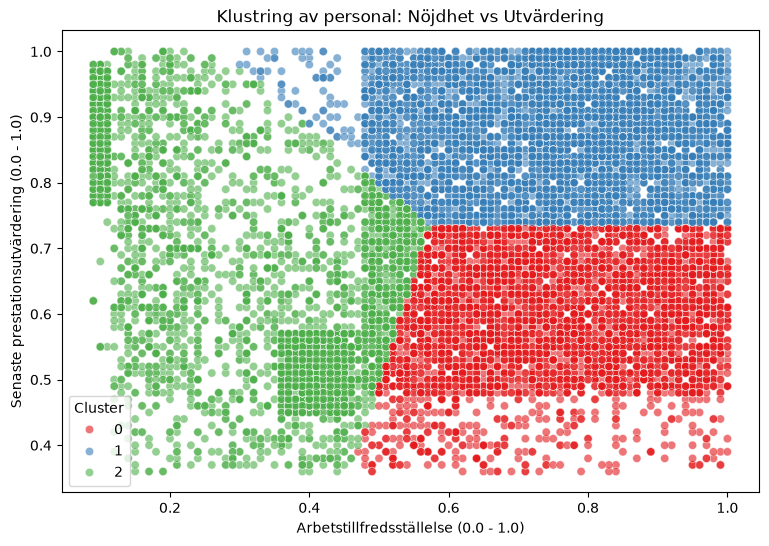

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Läs in datan
df = pd.read_excel("hr_employee_data.xlsx")

# 2. Välj variabler för klustring (vi ignorerar 'left' och fokuserar på prestation/nöjdhet)
X = df[['satisfaction_level', 'last_evaluation']]

# 3. Skalning av datan (alltid viktigt i K-means så inte en variabel tar över)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Träna K-means. Vi väljer 3 kluster som en rimlig indelning av personal.
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster'] = df['Cluster'].astype("category")

# 5. Visualisera våra nya personal-kluster
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='satisfaction_level', y='last_evaluation', hue='Cluster', palette='Set1', alpha=0.6)
plt.title('Klustring av personal: Nöjdhet vs Utvärdering')
plt.xlabel('Arbetstillfredsställelse (0.0 - 1.0)')
plt.ylabel('Senaste prestationsutvärdering (0.0 - 1.0)')
plt.show()